# Customer Churn Prediction in Telecom Sector

In [2]:
import pandas as pd
import warnings
import numpy as np


# Suppress all pandas warnings (only use if necessary)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# Use the correct file path to your SAVED, EDITED file
file_path = r"/content/Telco_Cusomer_Churn.csv"
df = pd.read_csv(file_path)

x=pd.DataFrame(df)

# ===========DATA VISUALIZATION===============

print(x.head)

print("check any duplicate row present : ",x.duplicated().sum())





FileNotFoundError: [Errno 2] No such file or directory: '/content/Telco_Cusomer_Churn.csv'

# Attribute Classification

In [ ]:
import pandas as pd

# 1. Create a list of columns and their types
type_info = []

for col in df.columns:
    # Check if the column is a number type
    if pd.api.types.is_numeric_dtype(df[col]):
        classification = "Numerical"
    else:
        classification = "Categorical"

    type_info.append({'Attribute': col, 'Data Type': df[col].dtype, 'Classification': classification})

# 2. Display as a clean Table
type_df = pd.DataFrame(type_info)
print("--- Attribute Classification ---")
print(type_df.to_string(index=False))

# 3. Summary Count
print("\nSummary:")
print(type_df['Classification'].value_counts())
print("NOTE FOR TotalCharges column because it contains 11 empty spaces it is treated as object rather than float")

--- Attribute Classification ---
       Attribute Data Type Classification
          gender    object    Categorical
   SeniorCitizen     int64      Numerical
         Partner    object    Categorical
      Dependents    object    Categorical
          tenure     int64      Numerical
    PhoneService    object    Categorical
   MultipleLines    object    Categorical
 InternetService    object    Categorical
  OnlineSecurity    object    Categorical
    OnlineBackup    object    Categorical
DeviceProtection    object    Categorical
     TechSupport    object    Categorical
     StreamingTV    object    Categorical
 StreamingMovies    object    Categorical
        Contract    object    Categorical
PaperlessBilling    object    Categorical
   PaymentMethod    object    Categorical
  MonthlyCharges   float64      Numerical
    TotalCharges   float64      Numerical
           Churn    object    Categorical

Summary:
Classification
Categorical    16
Numerical       4
Name: count, dtype: int6

# Data Preprocessing
# Filling Missing Values

In [ ]:
# --- 1. FILLING MISSING VALUES USING CODE ---

# 1a. TotalCharges (Numerical) - Missing 11 values
# Convert to numeric first, forcing blanks to NaN
df.loc[:, 'TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Imputation Technique: Fill with 0.0 (Correct for customers with tenure=0)
df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = 0.0

# 1b. MonthlyCharges (Numerical) - Missing 11 values
# Imputation Technique: Median Imputation (Robust for continuous data)
median_charges = df['MonthlyCharges'].median()
df.loc[df['MonthlyCharges'].isna(), 'MonthlyCharges'] = median_charges

# 1c. OnlineSecurity (Categorical) - Missing 11 values
# Imputation Technique: Mode Imputation (Correct for nominal categories)
mode_security = df['OnlineSecurity'].mode()[0]
df.loc[df['OnlineSecurity'].isna(), 'OnlineSecurity'] = mode_security

# --- 2. FINAL VERIFICATION ---
print("--- Imputation Complete for All 33 Missing Values ---")
print(f"TotalCharges missing count after filling:   {df['TotalCharges'].isnull().sum()}")
print(f"MonthlyCharges missing count after filling: {df['MonthlyCharges'].isnull().sum()}")
print(f"OnlineSecurity missing count after filling: {df['OnlineSecurity'].isnull().sum()}")


--- Imputation Complete for All 33 Missing Values ---
TotalCharges missing count after filling:   0
MonthlyCharges missing count after filling: 0
OnlineSecurity missing count after filling: 0


# Checking Missing Values

In [ ]:
# Check for standard missing values (NaN)
missing_values = df.isnull().sum()
print("--- Missing Values Per Column ---")
print(missing_values) # Only shows columns with issues

--- Missing Values Per Column ---
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Dropping Unimportant attribute for our prediction
# CustomerID

In [ ]:
# The 'errors=ignore' prevents the "not found" error if you run this cell twice
df.drop('customerID', axis=1, inplace=True, errors='ignore')

# --- VERIFICATION ---
print("--- CustomerID Attribute Dropped ---")
print(f"CustomerID column dropped? {'customerID' not in df.columns}")
print(f"Current number of columns: {len(df.columns)}")

--- CustomerID Attribute Dropped ---
CustomerID column dropped? True
Current number of columns: 20


# Check the remainning number of columns

In [ ]:
df.shape

(7043, 20)

# Data Transformation

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- STEP 0: SEPARATE TARGET ---
y = df['Churn']                 # keep class label unchanged
X = df.drop('Churn', axis=1)    # features only


# --- STEP 1: DATA REPAIR ---
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce').fillna(0)
X['MonthlyCharges'] = pd.to_numeric(X['MonthlyCharges'], errors='coerce').fillna(0)

# Drop high-cardinality ID column
X.drop('customerID', axis=1, inplace=True, errors='ignore')


# --- STEP 2: ENCODING CATEGORIES ---
X_encoded = pd.get_dummies(X, drop_first=True)


# --- STEP 3: MIN-MAX SCALING (FEATURES ONLY) ---
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_encoded),
    columns=X_encoded.columns,
    index=X_encoded.index
)


# --- STEP 4: REATTACH TARGET ---
df_final = pd.concat([X_scaled, y], axis=1)


# --- STEP 5: FINAL VERIFICATION ---
print("--- Transformation Verification ---")
print(f"Dataset Shape: {df_final.shape}")
print(f"Min value (features only): {X_scaled.values.min()}")
print(f"Max value (features only): {X_scaled.values.max()}")
print(f"Churn unique values: {df_final['Churn'].unique()}")
print(f"Any non-numeric feature columns left? {(X_scaled.dtypes == 'object').any()}")

print("\nFinal Transformed Data (First 5 rows):")
display(df_final.head())


NameError: name 'df' is not defined

# Training and Testing spliting of data set and
# Models that predict

# 1.Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# ===============================
# 1. FEATURES & TARGET
# ===============================
X = df_final.drop('Churn_Yes', axis=1)
y = df_final['Churn_Yes']

# ===============================
# 2. TRAIN–TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# 2b. FEATURE SCALING
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 3. LOGISTIC REGRESSION MODEL
# ===============================
log_model = LogisticRegression(
    penalty='l2',           # regularization type
    C=1.0,                  # inverse of regularization strength
    solver='lbfgs',         # solver for optimization
    max_iter=1000,           # ensure convergence
    random_state=42
)

log_model.fit(X_train, y_train)

# ===============================
# 4. PREDICTION
# ===============================
y_pred = log_model.predict(X_test)

# ===============================
# 5. EVALUATION
# ===============================
print("Logistic Regression Accuracy:", f"{accuracy_score(y_test, y_pred):.2%}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 80.48%

Confusion Matrix:
[[925 110]
 [165 209]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1035
         1.0       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



<Figure size 600x600 with 0 Axes>

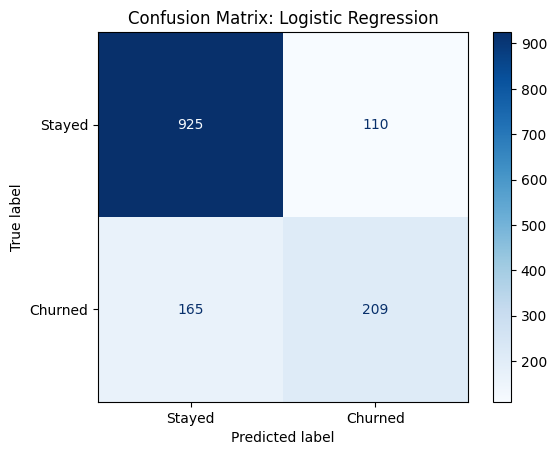

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting using ConfusionMatrixDisplay (Built on Matplotlib)
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Logistic Regression')
plt.show()

# 2.Decision tree

In [ ]:
import pandas as pd

# Load data fresh
df = pd.read_csv(r"Telco_Cusomer_Churn.csv")

# Drop ID
df.drop('customerID', axis=1, inplace=True)

# Fix numeric columns
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce').fillna(0)

# Encode categoricals INCLUDING churn
df_final = pd.get_dummies(df, drop_first=True)

print("df_final shape:", df_final.shape)


from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df_final.drop('Churn_Yes', axis=1)
y = df_final['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", f"{accuracy_score(y_test, y_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


df_final shape: (7043, 31)
Decision Tree Accuracy: 79.56%

Confusion Matrix:
[[917 118]
 [170 204]]

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.89      0.86      1035
        True       0.63      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



<Figure size 600x600 with 0 Axes>

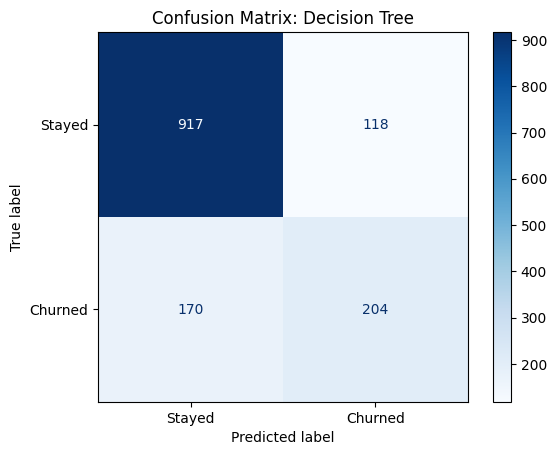

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Churned']
)
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Decision Tree')
plt.show()


# 3.Random Forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ===============================
# 1. FEATURES & TARGET
# ===============================
X = df_final.drop('Churn_Yes', axis=1)
y = df_final['Churn_Yes']

# ===============================
# 2. TRAIN–TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# 3. RANDOM FOREST MODEL
# ===============================
rf_model = RandomForestClassifier(
    n_estimators=300,        # number of trees
    max_depth=10,            # controls overfitting
    min_samples_split=50,
    min_samples_leaf=20,
    max_features='sqrt',     # best practice
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# ===============================
# 4. PREDICTION
# ===============================
y_pred = rf_model.predict(X_test)

# ===============================
# 5. EVALUATION
# ===============================
print("Random Forest Accuracy:", f"{accuracy_score(y_test, y_pred):.2%}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Random Forest Accuracy: 79.91%

Confusion Matrix:
[[946  89]
 [194 180]]

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.91      0.87      1035
        True       0.67      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



<Figure size 600x600 with 0 Axes>

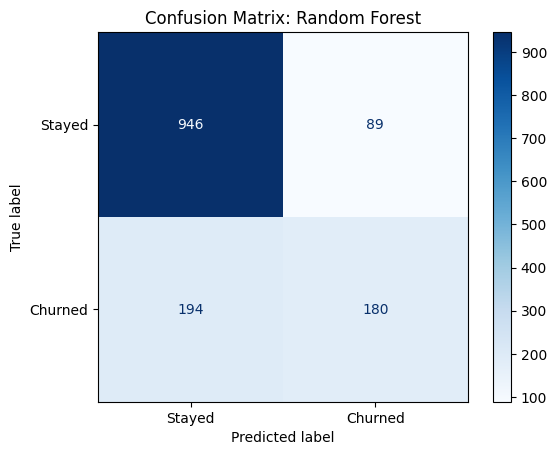

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Churned']
)
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Random Forest')
plt.show()


# 4.K-Nearest Neighbors (KNN) classifier

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# ===============================
# 1. FEATURES & TARGET
# ===============================
X = df_final.drop('Churn_Yes', axis=1)
y = df_final['Churn_Yes']

# ===============================
# 2. TRAIN–TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# 2b. FEATURE SCALING
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 3. KNN MODEL
# ===============================
knn_model = KNeighborsClassifier(
    n_neighbors=5,           # number of neighbors
    weights='uniform',       # all neighbors contribute equally
    p=2                      # Euclidean distance (p=2)
)

knn_model.fit(X_train, y_train)

# ===============================
# 4. PREDICTION
# ===============================
y_pred = knn_model.predict(X_test)

# ===============================
# 5. EVALUATION
# ===============================
print("KNN Accuracy:", f"{accuracy_score(y_test, y_pred):.2%}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


KNN Accuracy: 74.80%

Confusion Matrix:
[[867 168]
 [187 187]]

Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.84      0.83      1035
        True       0.53      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.75      1409



<Figure size 600x600 with 0 Axes>

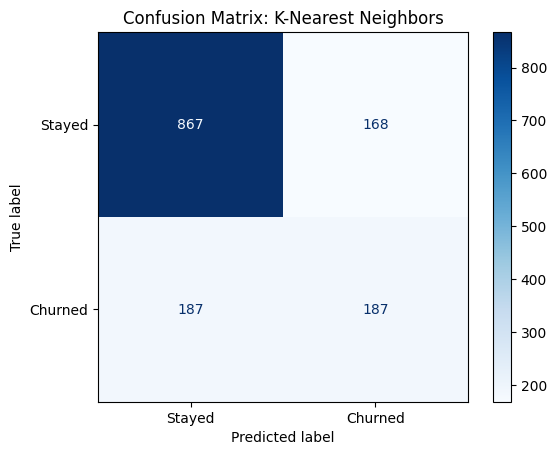

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Churned']
)
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: K-Nearest Neighbors')
plt.show()


# 5.Gradient Boosting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ===============================
# 1. FEATURES & TARGET
# ===============================
X = df_final.drop('Churn_Yes', axis=1)
y = df_final['Churn_Yes']

# ===============================
# 2. TRAIN–TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# 3. GRADIENT BOOSTING MODEL
# ===============================
gb_model = GradientBoostingClassifier(
    n_estimators=300,        # number of boosting stages
    learning_rate=0.05,      # step size shrinkage
    max_depth=3,             # depth of individual trees
    min_samples_split=50,
    min_samples_leaf=20,
    max_features='sqrt',     # controls feature selection
    random_state=42
)

gb_model.fit(X_train, y_train)

# ===============================
# 4. PREDICTION
# ===============================
y_pred = gb_model.predict(X_test)

# ===============================
# 5. EVALUATION
# ===============================
print("Gradient Boosting Accuracy:", f"{accuracy_score(y_test, y_pred):.2%}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Gradient Boosting Accuracy: 79.99%

Confusion Matrix:
[[933 102]
 [180 194]]

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1035
        True       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



<Figure size 600x600 with 0 Axes>

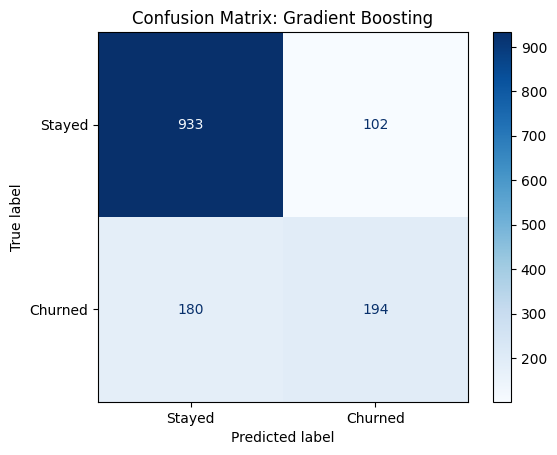

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Churned']
)
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Gradient Boosting')
plt.show()
